# COE 311K Final Project, Part 2
Individual project by Thomas Thomas (tlt2748)

## Introduction

My chosen system is the highly damped mechanical system. This stiff system is designed to respond very quickly to large transient forces, yet maintain stability over long, slow transient forces. The governing ODE is:

$$ \frac{dx}{dt}=-\frac{k}{c}x+\frac{1}{c}F(t) $$

The parameters and variables are:
- $\frac{dx}{dt}$: Velocity of the system
- $x$: Displacement of the system
- $k$: Spring constant, characterizes the force response to displacement
- $c$: Damping coefficient, characterizes the force response to velocity
- $F(t)$: Slow-moving external force

This system is only stiff at certain values of $k$ and $c$. The stiff version of this system is important in practice because many mechanical spring-damper systems are designed to adjust to slow-moving forces but react against fast-moving forces.

The parameter values for a stiff system are:

| Parameter | Value | Unit |
| :-: | :-: | :-: |
| $k$ | 5000 | N/m |
| $c$ | 1 | Ns/m |
| $F(t)$ | 200sin(t) | N |

Note, the spring constant and damping coefficients are chosen so that $\frac{k}{c}=5000s^{-1}$ as recommended for a very high damping rate.

## Demonstration of Stiffness

<ipython-input-1-e13af43e6037>:13: RuntimeWarning: overflow encountered in double_scalars
  f = lambda x, t: -(k/c)*x + 200*np.sin(t)/c
<ipython-input-1-e13af43e6037>:24: RuntimeWarning: invalid value encountered in double_scalars
  x_vals[i+1] = x_vals[i] + h * f(x_vals[i], t_vals[i])


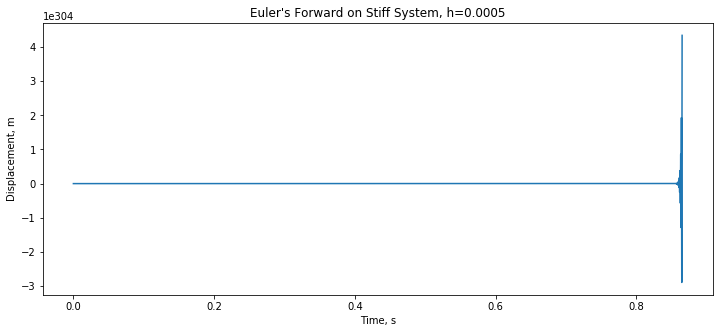

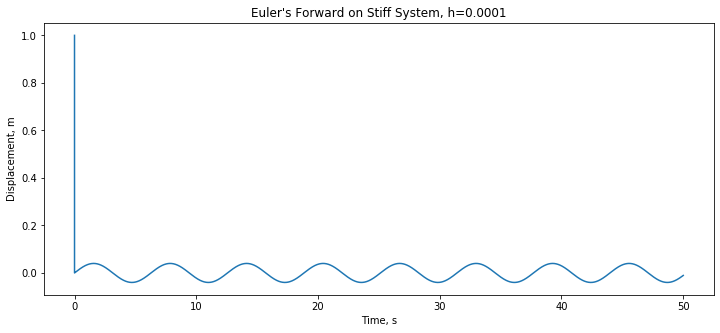

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Parameters
k = 5000 # N/m
c = 1 # Ns/m
t0 = 0 # s
tf = 50 # s
x0 = 1 # m

# Derivative function
f = lambda x, t: -(k/c)*x + 200*np.sin(t)/c

# Step sizes
h_vals = [0.0005, 0.0001]

# Forward Euler
for h in h_vals:
    t_vals = np.arange(t0, tf+h, h)
    x_vals = np.zeros_like(t_vals, dtype=float)
    x_vals[0] = x0
    for i in range(len(t_vals)-1):
        x_vals[i+1] = x_vals[i] + h * f(x_vals[i], t_vals[i])
    
    # plot result
    plt.figure(figsize=(12,5))
    plt.plot(t_vals, x_vals)
    plt.xlabel("Time, s")
    plt.ylabel("Displacement, m")
    plt.title(f"Euler's Forward on Stiff System, h={h}")
    plt.show()

For this stiff system, step sizes on the order of $5\times10^\text{-4}$ are unstable, hence the overflow error, while step sizes of $1\times10^\text{-4}$ are small enough to be stable but are computationally unnecessary for large time scales.

As this system is non-linear, the stiffness ratio is the ratio of time scales, which for this system is $10^1 / 10^\text{-3} = 10^4$. The system is stiff because it quickly eliminates fast transient forces (initial condition) but moves with slow transient forces (macro-scale sine function).

Euler's Forward stabilizes with a step size around $3\times10^\text{-4}$. With this step size, a time scale of 30 seconds would take $\frac{30}{3\times10^\text{-4}}=10^5$ step sizes, which is possible but unnecessary. Implicit methods like Euler's Backward with Newton-Raphson can solve the same stiff system with much larger step sizes, on the order of $0.05$.

## Mathematical Setup

The residual function for my specific problem is:

$$ g(x_{n+1})=x_{n+1}-x_n+h\cdot(\frac{k}{c}x-200\frac{sin(t)}{c})=0 $$

The derivative can be found analytically:

$$g'(x_{n+1})=1-h\cdot\frac{\partial f}{\partial x}\Bigg|_{t_{n+1}, x_{n+1}}$$

Where:

$$ f(x,t)=-\frac{k}{c}x+200\frac{sin(t)}{c} $$

Therefore $\frac{\partial f}{\partial x}=-\frac{k}{c}$, and:

$$ g'(x_{n+1})=1+\frac{hk}{c} $$

The Newton-Raphson update formula for my problem then becomes:

$$ y_{n+1}^{(k+1)}=y_{n+1}^{(k)}-\frac{g(y_{n+1}^{(k)})}{g'(y_{n+1}^{(k)})} $$


## Implementation

In [2]:
# The function (f) was defined earlier,
# in the Demonstration of Stiffness section.

# Derivative
g_prime = lambda h: 1 + h*(k/c)

# Newton-Raphson method
def newton_raphson_step(f, x_n, t, h, tol=1e-6, iterations=50):
    x_n1 = x_n
    for _ in range(iterations):
        g_val = x_n1 - x_n - h * f(x_n1, t+h)
        if abs(g_prime(h)) < tol:
            break
        x_new = x_n1 - g_val / g_prime(h)
        if abs(x_new - x_n1) < tol:
            return x_new
        x_n1 = x_new
    return x_n1

# Euler's Backward method, using Newton-Raphson
def euler_backward(f, x0, t0, tf, h, tol=1e-6, iterations=50):
    t_vals = np.arange(t0, tf+h, h)
    x_vals = np.zeros_like(t_vals)
    x_vals[0] = x0
    for i in range(len(t_vals)-1):
        x_vals[i+1] = newton_raphson_step(f, x_vals[i], t_vals[i], h, tol, iterations)
    return t_vals, x_vals

## Results and Analysis

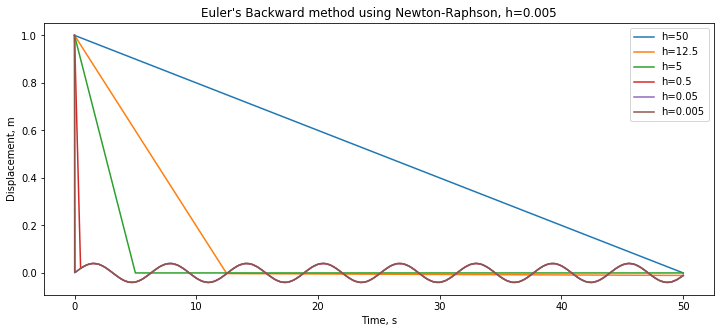

In [3]:
h_vals = [50, 12.5, 5, 0.5, 0.05, 0.005]

plt.figure(figsize=(12,5))
for h in h_vals:
    t_vals, y_vals = euler_backward(f, x0, t0, tf, h)
    plt.plot(t_vals, y_vals, label=f"h={h}")
plt.xlabel("Time, s")
plt.ylabel("Displacement, m")
plt.title(f"Euler's Backward method using Newton-Raphson, h={h}")
plt.legend()
plt.show()

The implicit solver of Euler's Backward using Newton Raphson is significantly more accurate at larger step sizes, up to $0.05$ for the fast-moving portion and $0.5$ for the slow oscillation portion. Beyond this, the method still converges; the step size just becomes too big relative to the oscillation period.

Compared to the explicit solver Euler's Forward, this implicit method is also much more stable. Euler's Forward destabilizes around step sizes of $0.0005$, while Euler's Backward with Newton-Raphson is stable up to step sizes of $12.5$ and beyond.

## Performance Analysis

Euler's Backward using Newton-Raphson is obviously more computationally demanding since it runs an iterative solver at every time step versus Euler's Forward just running one calculation. Despite this, the implicit method is much better at solving stiff systems like this one because of that additional calculation. This allows the implicit solver to generate accurate solutions at a much larger step size, meaning for stiff systems Euler's Backward with Newton-Raphson is the clear choice and my practical recommendation.

| Step Size | Converges with Euler's Forward? | Converges with Euler's Backward and Newton-Raphson? |
| :-: | :-: | :-: |
| 0.0001 | Yes | Yes |
| 0.0005 | No | Yes |
| 0.005 | No | Yes |
| 0.05 | No | Yes |
| 0.5 | No | After 0.5s |
| 5 | No | After 5s |
| 12.5 | No | After 12.5s |
| 50 | No | After 50s |

## Conclusions

My key finding in this part of the final project is that for stiff systems like this one, implicit solvers like Euler's Backward with Newton-Raphson are much more efficient than explicit solvers like Euler's Forward. I would've thought Euler's Forward would win even with a much smaller step size, but I underestimated just how large of a step size the implicit method could handle and still generate an accurate solution (2.5 orders of magnitude greater step size than the explicit method).

Overall, explicit methods are still very useful when the system is not stiff; however in the case of a stiff system, implicit methods are the right choice.